PROBABILITA' E DISTRIBUZIONE NEI MODELLI GENERATIVI

Immagina di voler dipengere una quadro che nessuno ha mai dipinto, ma che tutti riconoscono come reale.
Come fa il cervello a sapere dove mettere il colore? non ti ad invodvinare usa una mappa mentale delle probabilità accumulata in anni di osservazione
Vediamo come dare questa mappa alle macchine.
Passiamo dai pixel alla probabilità.

- Fondamenti statitici: Variabili, PDF, CDF, i pilastri che ci permettono di misurare l'incertezza
- Maximun Likelihood Estimation(MLE), la bussola che guida l'addestramento di ogni rete neurale moderna
- La Malediozione della Dimensionalità nel Deep Learning il motivo per cui generare un immagine è infinitimamente più difficile che lanciare un dado

Lingua che parlano i dati:
Il linguaggio mate
perchè un professore di AI parla di statistica?, perchè un modello generativo non è altro che un sofisticato esercizio di stima della distribuzione. Se non sappiamo descrivere matematicamente, ciò che già esiste (i nostri dati di addestramento) non avremmo mai speranza di creare qualcosa di nuovo. Pensa alla variabile aleatoria come un contenitore di possibilità
Pixel non è solo un numero, è il risultato di un processo che ha certo probabilità di accadere.

Come visualizzare matematicamente queste probabilita
Entriamo nel vivo con un PDF e la CDF
La PDF (Probability Density Function) è come una catena montuosa dove le cime sono più alte è più probabilie che i nostri dati cadano. Indica la densità di probabilità in un punto specifico dello spazio campionari.
Immagina un campione di 100 persone, molte persone pesano attorno ai 65 kg, poche attorno ai 40 kg ed poche attorno ai 100 kg. La PDF descrive questa forma, significa: valori vicino a 65 kg sono relarivamente frequenti.
Per una variabile continua la probabiltà di un singolo valore esatto (per esempio pesare esattamente 65 kg) è teroricamente molto bassa (quasi 0). 
Allo stesso tempo, la probabilità di pesare in un intervallo (per esempio da 60 kg a 70 kg) è matematicamente più alta e corrispondente alla PDF tra 60 e 70.
Una PDF alta indivisua zone con una maggiore concentrazione di dati e quindi una maggiore probabilità di ottenere valori in quell'intervallo.
La CDF (Cumulative Distribution Function) è come un contatore che accumula probabilità partendo da sinistra, rappresenta la probabilità che la variabile assuma un valore inferiore o uguale a un determinato punto.
Invece di chiedere "dove sono concentrati i dati?" la CDF chide "qual'è la probabilità che X sia minore o uguale a un certo intervallo?
Nell'esempio del peso: la CDF indica la distribuzione di un peso minore o uguale ad una soglia. es. il 72% della distribuzione ha peso minore o uguale a 70 kg
A differenza della PDF, la CDF non scenda mai
Riassumento
PDF
"Quanto sono concentrati i dati attorno ad un intervallo"
CDF
"Quanta probabilità ho accumulato fino ad un certo punto?"
Tra PDF e CDF c'è una relazione metemartica: la CDF è l'area accumulato sotto la PDF fino ad un punto x

Il campionamento è l'arte di sceglire un punto sotto le vette del PDF.
Cioè: estrarre un valore casuale secondo una determinata distribuzione di probabilità
Esemipo: supponi di avere 10 palline
6 rosso - 60% di probabilità
3 blu - 30% di probabiliità
1 verde - 10% di probabilità
Estrai una pallina, questa estrazione è un campione (o sample)
Ptrebbe uscire blu
campioniamo di nuovo, potrebbe uscire rosso, ecc
su 1000 campionamento mi aspetto circa: 600 rosso, 300 blu, 100 verdi
Quindi il campionamento non dice "scegli rosso perchè è il più probabile" ma dice:
"scegli casualmente, ma facendo si che rosso abbia molte più possibilità di essere scelto"

Con l'esempio delle palline, costruiamo una CDF (cioè una probabilità cumulata)
Immagina questa linea
0           0.60        0.90            1.00
|------------ | -------- | -------------|
    rosso       blu             verde
il rosso, avendo probabilità più alta, è messo per prima
ed ha CDF di 60
il blu, che ha probabilità 30%, la sua CDF accumula la CDF del rosso, quindi parte da 0.6 ed arriva a 0.9
Il verde ha probabiliità 10% parte dalla CDF accumulata del blu quindi da 0.9 ed arriva a 1
Rosso -> 0.6
Blu -> 0.6+0.3=0.9
Verde -> 0.6+0.3+0.1=1.0
Quindi la CDF dice quanta probabilità ho accumulato arrivando fino a quel colore

La CDF vista sui colori è una semplificazione giusto per far capire il concetto, in realtà non ha senso sui colori perchè non sono ordinabili, quindi è un concentto matematicamente artificiale.
Il problema della CDF nasce per una variabile ordinabile, per esempio l'altezza, temperature, vendite in kg, ecc

Nei modelli generativi, il campionamento consiste spesso nel trasformare una distribuzione semplice in una PDF complessa che ricalca i dati reali
Si campiona da una distribuzione semplice e il modello trasforma quei campioni in dati la cui distribuzione dovrebbe assomigliare a quella reale.


Ma attenzione, le vette che dobbiamo modellare noi, non sono semplici campane, sono paesaggi complessi con milioni di picchi.
Prendiamo una persona, e la caretteristica altezza
l'altrezza ha una distirbuzione grsso modo a campana, ma un'immagine (es. di una perosna) non ha solo una variabile (l'altezza) ne ha diverse di caretteristiche.
E' quindi una distribuzione in uno spazio con tantissime dimensioni
Quindi non è più possibile visualizzarla come una semplice campana, in quello spazio esistono regioni dove sono concentrate immagini plausibili.
E dentro le regioni "volti" ci sono ulteriori strutture:capelli chiari, capelli scuri, vista frontale, vista leterale, occhi aperti, ecc.
Una distribuzione con una sola zona ad alta probabilità è detta monomodale (es se misuro solo l'altezza)
Una distribuzione complessa, con più caratteristiche (come un volto) è detta multimodale

Saper calcolare l'area sotto questa curva, ciò che distingue un immagine coerente da rumore bianco.
cioò: un'immagine plausibile dovrebbe trovarsi in una regione dello spazio dei dati a elevata probabilità.

Ma una distribuzione non è fatta solo di curve, ha delle caratereristiche fisiche precise
cioè una distribuzione possiede proprietà statistiche precise
La media dice dove tende a concentrarsi la distribuzione
Varianza che misura quanto i valori sono dispersi

Caratterizzare le Distribuzioni
- Supporto della distribuzione: definisce l'intervallo di valori in cui la probabilità è diversa da zero, fondamentale per delimitare lo spazio di generazione. Il supporto ci dice dove è legale generare
- Momenti Statici: media e varianza descrivono la posizoine e la diffusione dei dati, parametri che la nostra rete neurale dovrà imparare a stiamre. Sono le prime cose che un modello impare, dove si trova il centro dei dati e quanto sono sparsi
- Trasformazione di Variabili: molti modelli (come Normaliziing Flows) si basano sul cambiamento di variabili per mappare rumore gaussiano in dati complessi.

Ma perchè non basta solo la statistica classica?
Mentra la statistica classica (statistica descrittiva)si concentra su poche variabili e si accontante di descrivere i dati, nei modelli generativi gestiamo milioni di dimensioni simultaneamente e vogliamo usare la statista come motere creativo.
Comprendere PDF e CDF è il prerequisito per capire come algoritmi come i VAE possano forzare lo spazio latente e seguire una distribuzione nota.
Vogliamo che il modello non spari nel mucchio, ma che capisca in quale intervallo di di probabilità si nasconde la qualità

come troviamo la distribuzione perffetta per i nostri dati?
qui entra in gioco la Maximun Likelihood Estimation (MLE)
Ottimizzare i parametri del modello
Come facciamo a dire alla nostra rete neurale che i parametri che ha scelto sono quelli giusti per rappresentare i dati? La risposta risiede nel principio di verosomiglianza
L'obbiettivo dell'addestramento è trovare i parametri theta che rendono i dati osservati i più probabili possibile secondo il modello.
Immagina di avre un mazzo di lenti fotografiche e dover scegliere quella che mette meglio a fuoco la realtà che avete davanti. MLE è il processo con cui proviamo tutte le lenti nei nostri paramtri finchè non troviamo quella che rende i dati che vogliamo i più probabili possibili. E' un atto di umiltà algoritmica, il modello si adatta alla realtà non viceversa

Ma come traduciamo questo in un linguaggio che il computer capisce?

Matematicamente cerchiamo il valore massimo di una funzione
Lavorare con le probabiìlità pure è pericoloso per un computer, moltiplicasre troppi numeri piccoli porta allo zero (underflow) per questo usiamo la Log-likelihood, trasformiamo i prodotti in somme e rendiamo tutto più stabile.
Quando senti parlare di cross-entropy nelle reti neurali, ricordati che stai facendo MLE sotto mentite spoglie, stasi cercanco di far si che un modello scommetta il pià possibile sui dasti reali.

Ma come si passa alla pratica dell'addestramento
Per funzionare MLE dobbiamo fare una scommessa
Assumiamo che i nostri dati siano indipendenti e identicamente distribuiti, è come dire che un immagine nel nostro dataset è un esperimento a se stante ma regolato dalle stesse leggi fiscihe.
Gli ottimizzatori amano scendere nelle valli,piuttosto che scalare le montagne, trasformiamo la massimizzazione della versosomiglianda nella minimizzazione della NLL (negative log likelihhhod), in pratica ogni volta che la rete sbagli la nll sale e l'algoritmo lavora per abassarla.

MLE è potente ma ha dei limiti
se la nostra distribuzione è troppo complessa il modello potrebbe decidere di ignorare alcune parte dei dati, per concentrarsi solo su una vetta facile da scalare, è il famoso model colapse, comprnderle aiuta a capire perchè alcune architettura (come normaliza frozern) cercano una verosomiglianza esatta, mentre alte (GAN) preferiscono  un approccio più artistico.
Ma ricorda, il modello perfetto è quello che assegna la stessa probabilità del mondo reale ad ogni possibile variante dei dati.

tutto questo sembra fattibile finchè non iniziamo ad aggiugere dimensioni

Entriamo nel conceteto della dimensionalità
Pensa a quanto è facile trovare un amico in una via retta, è più difficile in una piazze, ora prova in un cubo infinito di nebbia. Un immagine moderna ha milioni di pixel ed in quello spazio i dati non sono vicini, sono isole sperdute in un vuoto cosmico. La nostra intuizione geometrica quindi non ci serve più. dobbiamo imparare e pensare in spazi dove tutto è lontano.

Vediamo perchè questa lontananza rompe le rogole del gioco

Il problema è che in alta dimensione in volume esplode. Se volete coprire uniformemente uno spazio a 100 dimensioni, vi servirebbero ìpiù campioni di quanti atomi vi siano nell'universo.
Inoltre succede una cosa strana, in una gaussiana ad alta dimesione, la probabilità non sta al centro, ma si concentra in un guscio esterno sottile, quindi i dati devntano sparsi.
cercare di modellare questa densità è come cerca di colpire un avversario in una stanza buia
quale sono le conseguenze pratiche per chi lavora con il deep learning

La prima che il nostro training set, per quanto grande, è quasi sempre vuoto rispetto allo spazio possibile
L'ottimizzazione diventa un incubo, ci sono troppi modi per perderis
Tuttavia abbiamo un ancora di salveza
ka ManiFold Hypothessis, ipotiziamo che sebbene lo spazio dei pixel siano immense, le immagini vere occupano una piccola posizione. I modelli generativi hanno successo perchè imparano a navigare solo in quel sentiero sicuro ignorando il vuoto circostante.

Strategia di soppravivenza alla dimensionalità
dobbiamo usare un livello di compressione. 
proiettando i dati dall'abisso di alte dimensioni in uno spazio latente più piccolo e denso.

Immagina tutti i pixel di un immagine, ci sono infinite combinazioni, ma di queste combinazioni porta ad un'immagine sensata. Ed è proprio questo il problema che ci troviamo ad affrontare.

Versione Keras: 3.15.1 | Backend: torch
Inizio ottimizzazione dei parametri tramite MLE...
Media Reale definita: 5.0
Media Stimata dal modello dopo l'ottimizzazione: 4.6538


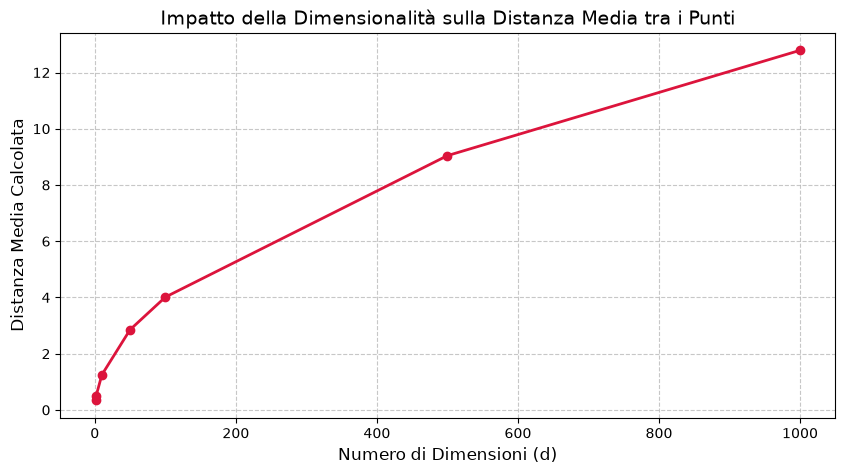

In [ ]:
import os

# Configurazione dell'ambiente di esecuzione.
# Impostiamo PyTorch come motore di calcolo (backend) per Keras prima di importare la libreria stessa.
os.environ["KERAS_BACKEND"] = "torch"

import keras
from keras import ops, layers
import numpy as np
import matplotlib.pyplot as plt

# Verifica della configurazione: stampa la versione di Keras e il backend effettivamente in uso.
print(f"Versione Keras: {keras.__version__} | Backend: {keras.backend.backend()}")

# --- GENERAZIONE DEI DATI REALI ---
# In questa sezione creiamo un dataset sintetico che funge da "verità di base".
# Ipotizziamo che i nostri dati seguano una distribuzione normale con una media (mu) specifica.
true_mu = 5.0
# Generiamo 1000 campioni estratti da una distribuzione normale centrata in 5.0 con deviazione standard 1.0.
# Il risultato è un array NumPy di forma (1000, 1) di tipo float32, compatibile con i tensori di Deep Learning.
data = np.random.normal(true_mu, 1.0, (1000, 1)).astype("float32")

# --- MODELLO DI MASSIMA VEROSIMIGLIANZA (MLE - Maximum Likelihood Estimation) ---
# L'obiettivo è costruire un modello che "impari" il parametro della media dai dati forniti.
# Creo un modello di un solo neurone (quindi inputs e dense) perche deve imparare una cosa semplicissima
# deve imparare output=input * peso
# Definiamo l'ingresso del modello: un singolo valore numerico per ogni record.
inputs = keras.Input(shape=(1,))

# Creiamo un livello Dense con un solo neurone. 
# Disabilitiamo il bias (use_bias=False) perché vogliamo che il peso del neurone rappresenti direttamente la nostra media stimata.
# Inizializziamo il peso a zero.
predicted_mu = layers.Dense(1, use_bias=False, kernel_initializer="zeros")(inputs)

# Colleghiamo ingressi e uscite per istanziare l'oggetto Model di Keras.
mle_model = keras.Model(inputs=inputs, outputs=predicted_mu)

# Definizione della funzione di perdita (Loss Function).
# Per una distribuzione normale con varianza nota e pari a 1, minimizzare la Negative Log-Likelihood (NLL)
# equivale a minimizzare l'errore quadratico medio (MSE).
def nll_loss(y_true, y_pred):  #come se fosse una MSE
    # Calcola lo scarto tra il dato reale e quello predetto, lo eleva al quadrato e ne fa la media.
    # Usiamo 'ops' di Keras per garantire la compatibilità con il backend PyTorch.
    return ops.mean(ops.square(y_true - y_pred))

# Compiliamo il modello specificando l'ottimizzatore Adam e la nostra funzione di perdita personalizzata.
mle_model.compile(optimizer="adam", loss=nll_loss)

# Fase di addestramento: il modello analizza i dati per regolare il suo peso interno (la media stimata).
# Poiché vogliamo che impari la media dei dati stessi, usiamo x=1  e data = target.
ones = np.ones((1000, 1)).astype("float32")

print("Inizio ottimizzazione dei parametri tramite MLE...")
mle_model.fit(ones, data, epochs=200, verbose=0)

# Recupero del parametro ottimizzato.
# Accediamo ai pesi del livello Dense (il secondo livello del modello, indice 1).
# Convertiamo il valore dal formato tensoriale del backend (PyTorch) a un array NumPy per la stampa.
estimated_mu = ops.convert_to_numpy(mle_model.layers[1].get_weights()[0][0][0])

print(f"Media Reale definita: {true_mu}")
print(f"Media Stimata dal modello dopo l'ottimizzazione: {estimated_mu:.4f}")

# --- ANALISI DELLA MALEDIZIONE DELLA DIMENSIONALITÀ ---
# Questa funzione illustra come la distanza tra i punti cambi drasticamente all'aumentare delle dimensioni dello spazio.
def check_dimensionality_curse(dims):
    avg_distances = []
    
    for d in dims:
        # Generiamo 100 punti casuali distribuiti uniformemente tra 0 e 1 in uno spazio a 'd' dimensioni.
        points = np.random.uniform(0, 1, (100, d)).astype("float32")
        
        # Calcolo delle distanze euclidee a coppie.
        # Espandiamo le dimensioni per sfruttare il broadcasting: trasformiamo i punti in una griglia di differenze.
        # diff[i][j] conterrà la differenza vettoriale tra il punto i e il punto j.
        diff = ops.expand_dims(points, 1) - ops.expand_dims(points, 0)
        
        # Calcoliamo la norma euclidea: radice quadrata della somma dei quadrati delle differenze lungo l'asse delle dimensioni.
        dist_matrix = ops.sqrt(ops.sum(ops.square(diff), axis=-1))
        
        # Calcoliamo la distanza media tra tutti i punti nel dataset generato.
        # Nota: questo include anche la distanza di ogni punto da se stesso (che è 0).
        avg_dist = ops.mean(dist_matrix)
        
        # Aggiungiamo il risultato alla lista convertendolo in formato numerico standard.
        avg_distances.append(ops.convert_to_numpy(avg_dist))
    
    return avg_distances

# Definiamo una serie di dimensioni crescenti da testare.
dimensions = [1, 2, 10, 50, 100, 500, 1000]
distances = check_dimensionality_curse(dimensions)

# --- VISUALIZZAZIONE GRAFICA DEI RISULTATI ---
# Creiamo un grafico per mostrare come la distanza media cresca con la complessità dimensionale.
plt.figure(figsize=(10, 5))
plt.plot(dimensions, distances, marker='o', color='crimson', linewidth=2)

plt.title("Impatto della Dimensionalità sulla Distanza Media tra i Punti", fontsize=14)
plt.xlabel("Numero di Dimensioni (d)", fontsize=12)
plt.ylabel("Distanza Media Calcolata", fontsize=12)

# Aggiungiamo una griglia per facilitare la lettura dei valori.
plt.grid(True, linestyle='--', alpha=0.7)

# Visualizziamo il grafico finale.
plt.show()